# Installations & Imports

In [1]:
!pip install cobra -q

In [2]:
import cobra
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from cobra import Reaction, Metabolite

# Bacillus

In [4]:
model = cobra.io.read_sbml_model("ecBSU1/model/iBsu1147_modify.xml")

'' is not a valid SBML 'SId'.
'R_BTDD-RR' is not a valid SBML 'SId'.
'R_BTDt6-RR' is not a valid SBML 'SId'.


lets find the important ids in the model

In [5]:
for ex in model.exchanges:
    name = (ex.name or "").lower()
    if any(k in name for k in ["oxygen", "nitrate", "nitrite", "sucrose", "fumarate"]):
        print(ex.id, "|", ex.name, "|", ex.bounds)

EX_o2_e | Oxygen exchange | (-1000.0, 0.0)
EX_no2_e | Nitrite exchange | (0.0, 1000.0)
EX_sucr_e | Sucrose exchange | (0.0, 1000.0)
EX_fum_e | Fumarate exchange | (0.0, 1000.0)
EX_no3_e | Nitrate exchange | (0.0, 1000.0)


lets look at the baseline aerobic and the growth with the anaerobic pathways

In [6]:
sol_aerobic = model.optimize()
print("aerobic:", sol_aerobic.objective_value)

print(model.reactions.get_by_id(atpm_id[0]).lower_bound)

with model:
    model.reactions.EX_o2_e.lower_bound = 0
    model.reactions.EX_no3_e.lower_bound = -10   # nitrate available
    sol_no3 = model.optimize()
    print("anaerobic + nitrate:", sol_no3.objective_value)

with model:
    model.reactions.EX_o2_e.lower_bound = 0
    model.reactions.EX_no3_e.lower_bound = 0     # fermentation only
    sol_ferm = model.optimize()
    print("fermentation only:", sol_ferm.objective_value)

aerobic: 0.39502675578002533


NameError: name 'atpm_id' is not defined

the anaerobic pathways give a near zero growth, why?

In [ ]:
for r in model.reactions:
    if "nitrate" in (r.name or "").lower() or "no3" in r.id.lower() or "no2" in r.id.lower():
        print(r.id, r.name, r.reaction, r.bounds)

EX_no2_e Nitrite exchange no2_e -->  (0.0, 1000.0)
EX_no3_e Nitrate exchange no3_e -->  (0.0, 1000.0)
NTRIR2x Nitrite reductase [NAD(P)H] small subunit (EC 1.7.1.4);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03300);Assimilatory nitrate reductase large subunit (EC:1.7.99.4)(BSU03310);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03320) 5.0 h_c + 3.0 nadh_c + no2_c --> 2.0 h2o_c + 3.0 nad_c + nh4_c (0.0, 1000.0)
NTRIR2y Nitrite reductase [NAD(P)H] small subunit (EC 1.7.1.4);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03300);Assimilatory nitrate reductase large subunit (EC:1.7.99.4)(BSU03310);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03320) 5.0 h_c + 3.0 nadph_c + no2_c --> 2.0 h2o_c + 3.0 nadp_c + nh4_c (0.0, 1000.0)
NO2t2r Nitrate/nitrite transporter;Formate/nitrite family of transporters(BSU38060) h_e + no2_e <=> h_c + no2_c (-1000.0, 1000.0)
NO2t3 Nitrate/nitrite transporter h_e + no2_c --> h_c + no2_e (0.0, 1000.0)
NO3t2 Nitrat

In [ ]:
nar = model.reactions.get_by_id("NTRIR2x")  # or whatever ID Check 1 turns up
print(nar.reaction)

5.0 h_c + 3.0 nadh_c + no2_c --> 2.0 h2o_c + 3.0 nad_c + nh4_c


: 

In [ ]:
with model:
    model.reactions.EX_o2_e.lower_bound = 0
    model.reactions.EX_no3_e.lower_bound = -10
    atpm_id = [r.id for r in model.reactions if "ATPM" in r.id or "maintenance" in (r.name or "").lower()]
    print(atpm_id)
    model.objective = atpm_id[0]
    print("max ATPM flux:", model.optimize().objective_value)

['ATPM']
max ATPM flux: 5.85


In [ ]:
bmodel.reactions.EX_glc__D_e.bounds = (-5,0)
bmodel.reactions.EX_glyc_e.bounds = (0,0)
bmodel.reactions.EX_o2_e.bounds = (-10,10)

In [ ]:
def add_dhordnad(model):
    """Adds DHORDnad — confirmed native, constitutive B. subtilis biology (PyrDI/PyrDII, Class 1B)."""
    model = model.copy()
    # Add NAD-dependent dihydroorotate dehydrogenase
    # Allows pyrimidine synthesis without O2
    # REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
    # REF: https://www.genome.jp/entry/bsu:BSU15540

    dhord_nad = cobra.Reaction("DHORDnad")
    dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
    dhord_nad.bounds = (0, 1000)
    dhord_nad.add_metabolites({
        model.metabolites.get_by_id("dhor__S_c"): -1,
        model.metabolites.get_by_id("nad_c"):    -1,
        model.metabolites.get_by_id("orot_c"):    +1,
        model.metabolites.get_by_id("nadh_c"):    +1,
        model.metabolites.get_by_id("h_c"):       +1,
    })
    model.add_reactions([dhord_nad])
    return model

def add_aspf

def bSubtilis_anaerobic_model(model):

    # Block oxygen
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0

    # Open nitrate as alternative electron acceptor
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000
    
    model = add_dhordnad(model)
    model = add_aspdh(model)


    return model

: 

# Objective1: Aerobic/Anaerobic Biomass- revised

In [ ]:
def add_aspofum(model):
    """ASPOfum — NadB (BSU27870) fumarate-linked mode, confirmed by Marinoni et al. 2008.
       Mirrors ASPO6 (the physiologically relevant, QULNS_1-feeding branch), not ASPO1."""
    m = model.copy()
    asp = m.metabolites.get_by_id("asp__L_c")
    iasp = m.metabolites.get_by_id("iasp_c")
    fum = m.metabolites.get_by_id("fum_c")
    succ = m.metabolites.get_by_id("succ_c")
    
    rxn = Reaction("ASPOfum")
    rxn.name = "L-aspartate oxidase, fumarate-linked (NadB, BSU27870)"
    rxn.bounds = (0, 1000)
    rxn.gene_reaction_rule = "BSU27870"
    rxn.add_metabolites({asp: -1, fum: -1, iasp: 1, succ: 1})
    m.add_reactions([rxn])
    return m

def add_dhordnad(model):
    """Adds DHORDnad — confirmed native, constitutive B. subtilis biology (PyrDI/PyrDII, Class 1B)."""
    model = model.copy()
    # Add NAD-dependent dihydroorotate dehydrogenase
    # Allows pyrimidine synthesis without O2
    # REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
    # REF: https://www.genome.jp/entry/bsu:BSU15540

    dhord_nad = cobra.Reaction("DHORDnad")
    dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
    dhord_nad.bounds = (0, 1000)
    dhord_nad.add_metabolites({
        model.metabolites.get_by_id("dhor__S_c"): -1,
        model.metabolites.get_by_id("nad_c"):    -1,
        model.metabolites.get_by_id("orot_c"):    +1,
        model.metabolites.get_by_id("nadh_c"):    +1,
        model.metabolites.get_by_id("h_c"):       +1,
    })
    model.add_reactions([dhord_nad])
    return model

def bSubtilis_corrected_model(model):
    """Applies both confirmed corrections unconditionally — aerobic and anaerobic alike."""
    m = add_dhordnad(model)
    m = add_aspofum(m)
    return m

def bSubtilis_anaerobic_model(model):
     # Block oxygen
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0

    # Open nitrate as alternative electron acceptor
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    #add the reactions that are confirmed to be present in B. subtilis
    m = add_dhordnad(model)
    m = add_aspofum(m)
    return m

In [ ]:
obj1_aerobic = bSubtilis_corrected_model(bmodel.copy())

In [ ]:
obj1_anaerobic = bSubtilis_anaerobic_model(bmodel.copy())

In [ ]:
obj1_aerobic.reactions.get_by_id("EX_o2_e").bounds = (-10,10)
obj1_aerobic.slim_optimize()

0.3191503372326128

In [ ]:
obj1_anaerobic.reactions.get_by_id("EX_o2_e").bounds = (0,10)
obj1_anaerobic.slim_optimize()

0.22170923056928044

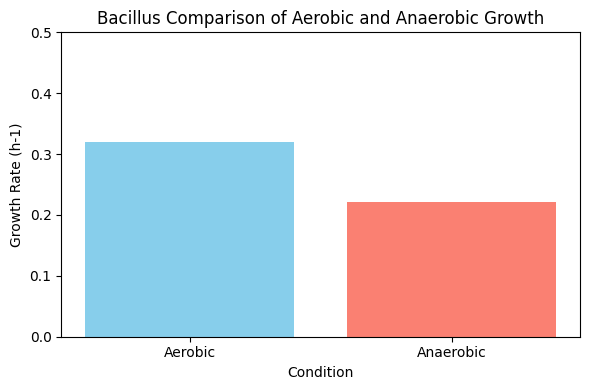

In [ ]:
# Data
categories = ['Aerobic', 'Anaerobic']
values = [obj1_aerobic.slim_optimize(), obj1_anaerobic.slim_optimize()]

# Plot configuration
plt.figure(figsize=(6, 4))
plt.bar(categories, values, color=['skyblue', 'salmon'])

# Labels and Title placeholders
plt.xlabel('Condition')
plt.ylabel('Growth Rate (h-1)')
plt.title('Bacillus Comparison of Aerobic and Anaerobic Growth')

# Set y-axis limit to 1.0 max
plt.ylim(0, 0.5)

plt.tight_layout()
plt.savefig("Bacillus_Biomass_Comaprison.png", dpi=150)
plt.show()

# Objective2: Minimum Oxygen for Viability

In [ ]:
obj2_aerobic = bmodel.copy()

In [ ]:
obj2_aerobic.reactions.get_by_id("EX_o2_e").bounds = (-10,10)
obj2_aerobic.slim_optimize()

0.3186056995116443

In [ ]:
obj2_anaerobic = bSubtilis_anaerobic_model(bmodel.copy())

In [ ]:
obj2_anaerobic.reactions.get_by_id("EX_o2_e").bounds = (0,10)
obj2_anaerobic.slim_optimize()

0.22170923056928044

Anaerobic growth : 0.2217 h⁻¹
Anaerobic CO₂   : 21.2670 mmol gDW⁻¹ h⁻¹

Max Growth        : 0.3186 h⁻¹
Viability threshold : 0.0159 h⁻¹  (5% of max)

Minimum viable O₂ uptake : 0.0503 mmol gDW⁻¹ h⁻¹
Growth at that point     : 0.0726 h⁻¹
CO₂ at that point        : 9.2262 mmol gDW⁻¹ h⁻¹


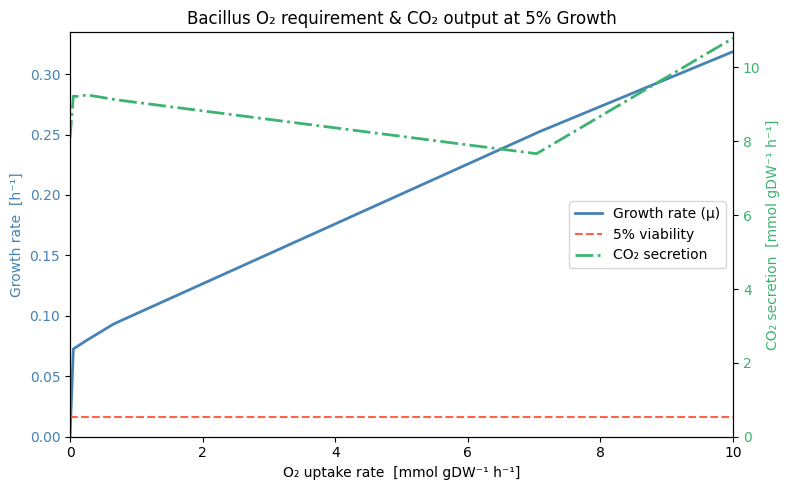

In [ ]:
o2_rxn_id = "EX_o2_e"
co2_rxn_id = "EX_co2_e" # CO2 exchange

# ── 2. Anaerobic reference ───────────────
with obj2_anaerobic:
    sol_ana = obj2_anaerobic.optimize()
    anaerobic_growth = sol_ana.objective_value
    anaerobic_co2    = sol_ana.fluxes[co2_rxn_id]

print(f"Anaerobic growth : {anaerobic_growth:.4f} h⁻¹")
print(f"Anaerobic CO₂   : {anaerobic_co2:.4f} mmol gDW⁻¹ h⁻¹")

# ── 3. Max aerobic growth & viability threshold ───────────────────────────────
with obj2_aerobic:
    sol_max = obj2_aerobic.optimize()
    maxGrowth  = sol_max.objective_value

viability_threshold = 0.05 * maxGrowth
print(f"\nMax Growth        : {maxGrowth:.4f} h⁻¹")
print(f"Viability threshold : {viability_threshold:.4f} h⁻¹  (5% of max)")

# ── 4. Scan O₂ — record growth AND CO₂ ───────────────────────────────────────
o2_max_uptake = abs(obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

growth_rates = []
co2_fluxes   = []

with obj2_aerobic:
    for o2 in o2_scan:
        obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = obj2_aerobic.optimize()

        if sol.status == "optimal":
            growth_rates.append(sol.objective_value)
            co2_fluxes.append(sol.fluxes[co2_rxn_id])
        else:
            growth_rates.append(0.0)
            co2_fluxes.append(0.0)

growth_rates = np.array(growth_rates)
co2_fluxes   = np.array(co2_fluxes)

# ── 5. Minimum viable O₂ ─────────────────────────────────────────────────────
viable_mask = growth_rates >= viability_threshold
if viable_mask.any():
    min_viable_o2 = o2_scan[viable_mask][0]
    growth_at_min = growth_rates[viable_mask][0]
    co2_at_min    = co2_fluxes[viable_mask][0]
    print(f"\nMinimum viable O₂ uptake : {min_viable_o2:.4f} mmol gDW⁻¹ h⁻¹")
    print(f"Growth at that point     : {growth_at_min:.4f} h⁻¹")
    print(f"CO₂ at that point        : {co2_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ln1 = ax1.plot(o2_scan, growth_rates, color="steelblue", lw=2, label="Growth rate (μ)")
ax1.axhline(viability_threshold, color="tomato", lw=1.5, ls="--", label=f"5% viability")

ln2 = ax2.plot(o2_scan, co2_fluxes, color="mediumseagreen", lw=2, ls="-.", label="CO₂ secretion")

ax1.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax1.set_ylabel("Growth rate  [h⁻¹]", color="steelblue")
ax2.set_ylabel("CO₂ secretion  [mmol gDW⁻¹ h⁻¹]", color="mediumseagreen")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="mediumseagreen")

ax1.set_xlim(0, o2_max_uptake)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Bacillus O₂ requirement & CO₂ output at 5% Growth")
plt.tight_layout()
plt.show()

# Objective4: Alternative carbon sources for bascillus

## initial attempts with the old model, without ASPFUM, anaerobic sucrose growth was higher than aerobic sucrose growth (?)

In [ ]:
obj_4_aerobic =  bmodel.copy()
obj_4_anaerobic= bSubtilis_anaerobic_model(bmodel.copy())

In [ ]:
# Search for sucrose-related reactions and metabolites
for rxn in obj_4_aerobic.reactions:
    if "sucr" in rxn.id.lower() or "sucrose" in rxn.name.lower():
        print(f"ID: {rxn.id} | Name: {rxn.name}")
        print(f"Equation: {rxn.reaction}")
        print(f"Bounds : {rxn.bounds}\n")

for met in obj_4_aerobic.metabolites:
    if "sucr" in met.id.lower() or "sucrose" in met.name.lower():
        print(f"ID: {met.id} | Name: {met.name}")

ID: EX_sucr_e | Name: Sucrose exchange
Equation: sucr_e --> 
Bounds : (0.0, 1000.0)

ID: RAFH | Name: Sucrose-6-phosphate hydrolase (EC 3.2.1.26)
Equation: h2o_c + raffin_c <=> fru_c + melib_c
Bounds : (-1000.0, 1000.0)

ID: FFSD | Name: Sucrose-6-phosphate hydrolase (EC 3.2.1.26)
Equation: h2o_c + suc6p_c <=> fru_c + g6p_A_c
Bounds : (-1000.0, 1000.0)

ID: SUCpts | Name: Phosphoenolpyruvate-protein phosphotransferase of PTS system (EC 2.7.3.9);PTS system, sucrose-specific IIB component (EC 2.7.1.69)|PTS system, sucrose-specific IIC component (EC 2.7.1.69)(BSU38050);PTS system, sucrose-specific IIB component; PTS system, sucrose-specific IIC component(BSU38410);Phosphocarrier protein of PTS system(BSU13900)
Equation: pep_c + sucr_e --> pyr_c + suc6p_c
Bounds : (0.0, 1000.0)

ID: sucr_c | Name: Sucrose
ID: sucr_e | Name: Sucrose, extracellular
ID: suc6p_c | Name: Sucrose 6-phosphate


: 

: 

: 

: 

: 

now that we verified that sucrose reactions exist, lets open up sucrose and close glucose

In [ ]:
def test_carbon_source(base_model, carbon_ex_id, uptake_rate=-5, anaerobic=False):
    m = base_model.copy()
    m.reactions.EX_glc__D_e.bounds = (0, 1000)      # close glucose
    m.reactions.EX_sucr_e.bounds = (0, 1000)         # close sucrose by default
    m.reactions.get_by_id(carbon_ex_id).bounds = (uptake_rate, 1000)  # open target
    
    if anaerobic:
        m = bSubtilis_anaerobic_model(m)
        m.reactions.EX_o2_e.bounds = (0, 10)
    else:
        m.reactions.EX_o2_e.bounds = (-10, 10)
    
    return m.slim_optimize()

In [ ]:
results = {
    "Glucose (aerobic)":   test_carbon_source(obj_4_aerobic, "EX_glc__D_e", -5, anaerobic=False),
    "Sucrose (aerobic)":   test_carbon_source(obj_4_aerobic, "EX_sucr_e",  -5, anaerobic=False),
    "Glucose (anaerobic)": test_carbon_source(obj_4_anaerobic, "EX_glc__D_e", -5, anaerobic=True),
    "Sucrose (anaerobic)": test_carbon_source(obj_4_anaerobic, "EX_sucr_e",  -5, anaerobic=True),
}
for k, v in results.items():
    print(f"{k}: {v:.4f} h⁻¹")

Ignoring reaction 'DHORDnad' since it already exists.
Ignoring reaction 'ASPOfum' since it already exists.
Ignoring reaction 'DHORDnad' since it already exists.
Ignoring reaction 'ASPOfum' since it already exists.


Glucose (aerobic): 0.3186 h⁻¹
Sucrose (aerobic): 0.4487 h⁻¹
Glucose (anaerobic): 0.2217 h⁻¹
Sucrose (anaerobic): 0.4784 h⁻¹


## fixing error: ASPDH not native, anaerobic and aerobic model not comparable

whats strange is that sucrose anaerobic growth rate is higher than anaerobic (?)

lets first ensure that indeed the oxygen flux is zero in the anaerobic model

In [ ]:
# isolate: does anaerobic sucrose beat aerobic sucrose only because of the added reactions,
# or because of an actual bound leak?
m = obj_4_aerobic.copy()
m.reactions.EX_glc__D_e.bounds = (0, 1000)
m.reactions.EX_sucr_e.bounds = (-5, 1000)
m.reactions.EX_o2_e.bounds = (-10, 10)
print("Sucrose aerobic, no anaerobic mods:", m.slim_optimize())

m2 = obj_4_anaerobic.copy()
m2.reactions.EX_glc__D_e.bounds = (0, 1000)
m2.reactions.EX_sucr_e.bounds = (-5, 1000)
m2.reactions.EX_o2_e.bounds = (0, 10)
print("Sucrose anaerobic:", m2.slim_optimize())

# Confirm O2 uptake in each solution
sol_aero = m.optimize()
sol_ana = m2.optimize()
print("Aerobic O2 flux:", sol_aero.fluxes["EX_o2_e"])
print("Anaerobic O2 flux:", sol_ana.fluxes["EX_o2_e"])

Sucrose aerobic, no anaerobic mods: 0.4487187029006023
Sucrose anaerobic: 0.47844741619696035
Aerobic O2 flux: -10.0
Anaerobic O2 flux: 0.0


this could be because the aerobic model does not have the bypass reactions, let's add them (although i think they'd be inactive aerobically..)
s

In [ ]:
# Aerobic model WITH the bypass reactions added, O2 still fully open
m3 = bSubtilis_anaerobic_model(bmodel.copy())   # adds DHORDnad + ASPDH
m3.reactions.EX_o2_e.bounds = (-10, 10)          # but O2 stays open, not forced off!
m3.reactions.EX_glc__D_e.bounds = (0, 1000)
m3.reactions.EX_sucr_e.bounds = (-5, 1000)
print("Sucrose, O2 open, WITH bypass reactions:", m3.slim_optimize())

Sucrose, O2 open, WITH bypass reactions: 0.6093281397066099


: 

: 

: 

: 

: 

but can these pathways be active aerobically is the question? literature says that the DHORDnad pathway can be, but what about the ASPDH pathway? lets check if there is NAD salvage pathway natively

In [ ]:
# Look for NAD salvage pathway reactions and exchanges
salvage_terms = ["nicotinamide", "nicotinate", "nmn", "namn", "naad", "pnc", "pnu", "nadv", "nade"]
for rxn in bmodel.reactions:
    name = (rxn.name or "").lower()
    if any(term in name or term in rxn.id.lower() for term in salvage_terms):
        print(rxn.id, "|", rxn.name, "|", rxn.reaction, "|", rxn.bounds)

# Check specifically for exchange reactions that could supply these in medium
for ex in bmodel.exchanges:
    name = (ex.name or "").lower()
    if any(term in name for term in salvage_terms):
        print("EXCHANGE:", ex.id, ex.name, ex.bounds)

EX_nac_e | Nicotinate exchange | nac_e -->  | (0.0, 1000.0)
NMNAT | Nicotinate-nucleotide adenylyltransferase (EC 2.7.7.18) | atp_c + nmn_c --> nad_c + ppi_c | (0.0, 1000.0)
NAMNPP | Nicotinate phosphoribosyltransferase (EC 2.4.2.11) | nicrnt_c + ppi_c <=> h_c + nac_c + prpp_c | (-1000.0, 1000.0)
NMNR | 5'-nucleotidase yjjG (EC 3.1.3.5);2',3'-cyclic-nucleotide 2'-phosphodiesterase (EC 3.1.4.16)|5'-nucleotidase (EC 3.1.3.5)(BSU07840) | h2o_c + nmn_c --> h_c + pi_c + rnam_c | (0.0, 1000.0)
NNATr | Nicotinate-nucleotide adenylyltransferase (EC 2.7.7.18) | atp_c + nicrnt_c --> dnad_c + ppi_c | (0.0, 1000.0)
PPNCL2 | Phosphopantothenoylcysteine decarboxylase (EC 4.1.1.36)|Phosphopantothenoylcysteine synthetase (EC 6.3.2.5) | 4ppan_c + ctp_c + cys__L_c --> 4ppcys_c + cmp_c + ppi_c | (0.0, 1000.0)
EXCHANGE: EX_nac_e Nicotinate exchange (0.0, 1000.0)


: 

: 

: 

: 

: 

In [ ]:
with obj_4_aerobic.copy() as m:
    m = add_dhordnad(m)          # DHORD only — no ASPDH
    m.reactions.EX_o2_e.lower_bound = 0
    m.reactions.EX_no3_e.lower_bound = -10
    m.reactions.EX_nac_e.lower_bound = -10   # nicotinate salvage open
    sol = m.optimize()
    print("DHORD + salvage, no ASPDH:", sol.objective_value)

DHORD + salvage, no ASPDH: 0.13813226853606145


: 

In [ ]:
for rxn in bmodel.reactions:
    mets = [m.id for m in rxn.metabolites]
    if "nac_e" in mets and "nac_c" in mets:
        print(rxn.id, rxn.name, rxn.reaction, rxn.bounds)

NACt  nac_e <=> nac_c (-1000.0, 1000.0)


: 

indeed, we do see that the growth opens up with nicotinamde uptake open (but this would mean we'd have to supply that)



In [ ]:
for rxn in bmodel.reactions:
    mets = [m.id for m in rxn.metabolites]
    if "dnad_c" in mets and "nad_c" in mets:
        print(rxn.id, rxn.name, rxn.reaction, rxn.bounds)

NADS1n NAD synthetase (EC 6.3.1.5) atp_c + dnad_c + nh4_c --> amp_c + nad_c + ppi_c (0.0, 1000.0)


: 

is there a native reaction that would do nad+ biosynthesis (literature backed up) ASPO6 does, is it there? the previously found gene from KEGG, ASPDH isn't natively there and no literature shows it to be present in bascillus by default

In [ ]:
aspo6 = bmodel.reactions.get_by_id("ASPO6")
print("Reaction:", aspo6.reaction)
print("Genes:", [g.id for g in aspo6.genes])
print("GPR rule:", aspo6.gene_reaction_rule)

Reaction: asp__L_c + o2_c --> h2o2_c + h_c + iasp_c
Genes: ['BSU27870']
GPR rule: BSU27870


: 

In [ ]:
for rxn in bmodel.reactions:
    if "BSU27870" in rxn.gene_reaction_rule:
        print(rxn.id, "|", rxn.name, "|", rxn.reaction)


ASPO1 | L-aspartate oxidase (EC 1.4.3.16) | asp__L_c + h2o_c + o2_c --> h2o2_c + nh4_c + oaa_c
ASPO6 | L-aspartate oxidase (EC 1.4.3.16) | asp__L_c + o2_c --> h2o2_c + h_c + iasp_c


In [ ]:
#ensure that aspo1 is a redundant pathway to aspo6, not a required one
sol = bmodel.optimize()
print("ASPO6 flux:", sol.fluxes["ASPO6"])
print("ASPO1 flux:", sol.fluxes["ASPO1"])

ASPO6 flux: 0.006215901615764686
ASPO1 flux: 0.0


In [ ]:
for rxn in bmodel.reactions:
    if "iasp_c" in [m.id for m in rxn.metabolites] and rxn.id != "ASPO6":
        print(rxn.id, rxn.name, rxn.reaction)

QULNS_1 Quinolinate synthetase (EC 4.1.99.-) dhap_c + iasp_c --> 2.0 h2o_c + h_c + pi_c + quln_c


## **corrected anaerobic model** 
Add the missing pathway for the ASPO6 reaction- the confirmed anaerobic path

Okay we have verified  L-aspartate oxidase exists, it uses oxygen to regenerate nad+. but anaerobically, it uses fumarate instead of oxygen to regenrate nad+. this is backed up by literature but missing in the current model. lets correct our current anaerobic model to include aspofum instead of aspdh

In [ ]:
def add_aspofum(model):
    """ASPOfum — NadB (BSU27870) fumarate-linked mode, confirmed by Marinoni et al. 2008.
       Mirrors ASPO6 (the physiologically relevant, QULNS_1-feeding branch), not ASPO1."""
    m = model.copy()
    asp = m.metabolites.get_by_id("asp__L_c")
    iasp = m.metabolites.get_by_id("iasp_c")
    fum = m.metabolites.get_by_id("fum_c")
    succ = m.metabolites.get_by_id("succ_c")
    
    rxn = Reaction("ASPOfum")
    rxn.name = "L-aspartate oxidase, fumarate-linked (NadB, BSU27870)"
    rxn.bounds = (0, 1000)
    rxn.gene_reaction_rule = "BSU27870"
    rxn.add_metabolites({asp: -1, fum: -1, iasp: 1, succ: 1})
    m.add_reactions([rxn])
    return m

def bSubtilis_corrected_model(model):
    """Applies both confirmed corrections unconditionally — aerobic and anaerobic alike."""
    m = add_dhordnad(model)
    m = add_aspofum(m)
    return m

In [ ]:
# Quick check: does the corrected model have no flux through the ASPOfum pathway aerobically?
m = bSubtilis_corrected_model(bmodel.copy())
m.reactions.EX_o2_e.bounds = (-10, 10)   # aerobic
sol = m.optimize()

print("ASPO6 flux:", sol.fluxes["ASPO6"])
print("ASPOfum flux:", sol.fluxes["ASPOfum"])

ASPO6 flux: 0.0
ASPOfum flux: 0.006226527334306027


## sucr vs glu test
let us re-run the sucrose-glucose comparison for aerobic and anaerobic conditions

lets normalize this per mol of carbon, since one mole of glucose isn't equivalent to one mol of sucrose

In [ ]:
def test_condition(base_model, carbon_ex_id, uptake_rate=-5, anaerobic=False):
    m = bSubtilis_corrected_model(base_model.copy())
    m.reactions.EX_glc__D_e.bounds = (0, 1000)
    m.reactions.EX_sucr_e.bounds = (0, 1000)
    m.reactions.get_by_id(carbon_ex_id).bounds = (uptake_rate, 1000)
    
    if anaerobic:
        m.reactions.EX_o2_e.bounds = (0, 10)
        m.reactions.EX_no3_e.lower_bound = -10
    else:
        m.reactions.EX_o2_e.bounds = (-10, 10)
    
    return m.slim_optimize()

for label, ex_id, anaer in [
    ("Glucose (aerobic)",   "EX_glc__D_e", False),
    ("Sucrose (aerobic)",   "EX_sucr_e",  False),
    ("Glucose (anaerobic)", "EX_glc__D_e", True),
    ("Sucrose (anaerobic)", "EX_sucr_e",  True),
]:
    print(f"{label}: {test_condition(bmodel, ex_id, -5, anaer):.4f} h⁻¹")
    C_per_mol = sucrose_C_per_mol if "Sucrose" in label else glucose_C_per_mol
    C_uptake = uptake_magnitude * C_per_mol
    print(f"{label}: {test_condition(bmodel, ex_id, -5, anaer):.4f} h⁻¹  |  {test_condition(bmodel, ex_id, -5, anaer)/C_uptake:.6f} h⁻¹ per mmol C")

Glucose (aerobic): 0.3192 h⁻¹
Glucose (aerobic): 0.3192 h⁻¹  |  0.010638 h⁻¹ per mmol C
Sucrose (aerobic): 0.4495 h⁻¹
Sucrose (aerobic): 0.4495 h⁻¹  |  0.007492 h⁻¹ per mmol C
Glucose (anaerobic): 0.1380 h⁻¹
Glucose (anaerobic): 0.1380 h⁻¹  |  0.004601 h⁻¹ per mmol C
Sucrose (anaerobic): 0.2786 h⁻¹
Sucrose (anaerobic): 0.2786 h⁻¹  |  0.004643 h⁻¹ per mmol C


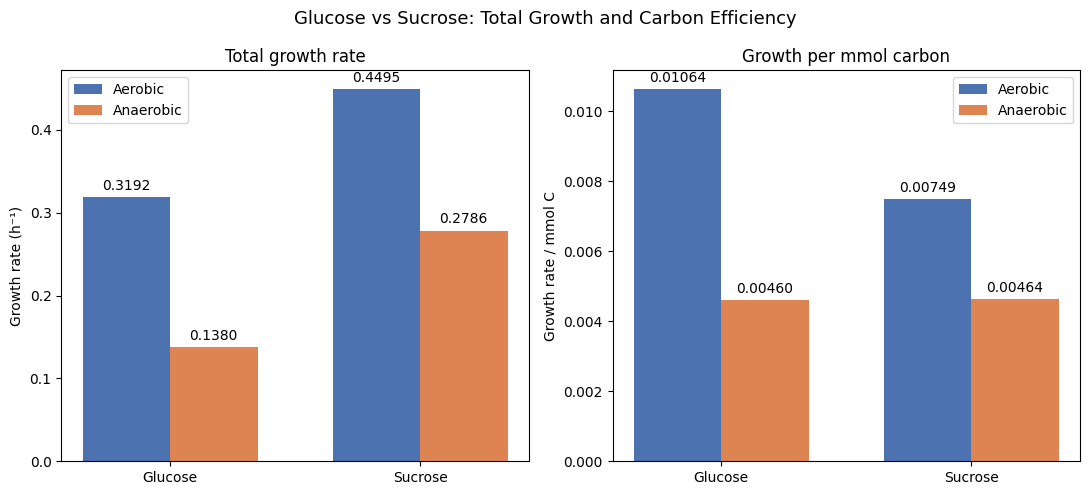

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["Glucose", "Sucrose"]
x = np.arange(len(categories))
width = 0.35

aerobic_total = [0.3192, 0.4495]
anaerobic_total = [0.1380, 0.2786]
aerobic_perC = [0.010638, 0.007492]
anaerobic_perC = [0.004601, 0.004643]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left plot: total growth rate
bars1 = axes[0].bar(x - width/2, aerobic_total, width, label="Aerobic", color="#4C72B0")
bars2 = axes[0].bar(x + width/2, anaerobic_total, width, label="Anaerobic", color="#DD8452")
axes[0].set_title("Total growth rate")
axes[0].set_ylabel("Growth rate (h⁻¹)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].bar_label(bars1, fmt="%.4f", padding=3)
axes[0].bar_label(bars2, fmt="%.4f", padding=3)

# Right plot: per-carbon efficiency
bars3 = axes[1].bar(x - width/2, aerobic_perC, width, label="Aerobic", color="#4C72B0")
bars4 = axes[1].bar(x + width/2, anaerobic_perC, width, label="Anaerobic", color="#DD8452")
axes[1].set_title("Growth per mmol carbon")
axes[1].set_ylabel("Growth rate / mmol C")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].bar_label(bars3, fmt="%.5f", padding=3)
axes[1].bar_label(bars4, fmt="%.5f", padding=3)

fig.suptitle("Glucose vs Sucrose: Total Growth and Carbon Efficiency", fontsize=13)
plt.tight_layout()
plt.savefig("growth_comparison_combined.png", dpi=300)
plt.show()

# Objective3: Minimum Oxygen for Viability while producing proteins

In [ ]:
obj3_master_model = bmodel.copy()

: 

## Adding GFP + Anti-GFP Nanobody Reactions

### Create the Amino Acids Dictionary

In [ ]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in obj3_master_model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]


: 

In [ ]:
for m in bmodel.metabolites:
  if "Glycine" in m.name:
    print(m.id)
    print(m.name)

gly_c
Glycine
gly_e
Glycine, extracellular


: 

In [ ]:
# Mapping of amino acid single letters to their likely IDs in the iBsu1147 model
aa_metabolites_ids = {
    'A': 'ala__L_c', 'R': 'arg__L_c', 'N': 'asn__L_c', 'D': 'asp__L_c',
    'C': 'cys__L_c', 'Q': 'gln__L_c', 'E': 'glu__L_c', 'G': 'gly_c',
    'H': 'his__L_c', 'I': 'ile__L_c', 'L': 'leu__L_c', 'K': 'lys__L_c',
    'M': 'met__L_c', 'F': 'phe__L_c', 'P': 'pro__L_c', 'S': 'ser__L_c',
    'T': 'thr__L_c', 'W': 'trp__L_c', 'Y': 'tyr__L_c', 'V': 'val__L_c'
}

aa_metabolites = {}
for letter, mid in aa_metabolites_ids.items():
    try:
        aa_metabolites[letter] = obj3_master_model.metabolites.get_by_id(mid)
    except KeyError:
        # Fallback: try searching by name if the standard ID doesn't work
        name_to_search = aa_names[letter].lower()
        hits = [m for m in obj3_master_model.metabolites if m.name.lower() == name_to_search and m.compartment == 'c']
        if hits:
            aa_metabolites[letter] = hits[0]
        else:
          print(f"Warning: No metabolite found for {letter} ({name_to_search})")

print(f"Loaded {len(aa_metabolites)}/20 amino acids.")
for letter, met in sorted(aa_metabolites.items()):
    print(f"  {letter} | {met.id} | {met.name}")

Loaded 20/20 amino acids.
  A | ala__L_c | L-Alanine
  C | cys__L_c | L-Cysteine
  D | asp__L_c | L-Aspartate
  E | glu__L_c | L-Glutamate
  F | phe__L_c | L-Phenylalanine
  G | gly_c | Glycine
  H | his__L_c | L-Histidine
  I | ile__L_c | L-Isoleucine
  K | lys__L_c | L-Lysine
  L | leu__L_c | L-Leucine
  M | met__L_c | L-Methionine
  N | asn__L_c | L-Asparagine
  P | pro__L_c | L-Proline
  Q | gln__L_c | L-Glutamine
  R | arg__L_c | L-Arginine
  S | ser__L_c | L-Serine
  T | thr__L_c | L-Threonine
  V | val__L_c | L-Valine
  W | trp__L_c | L-Tryptophan
  Y | tyr__L_c | L-Tyrosine


: 

### Assign Variables to important molecules

In [ ]:
atp  = obj3_master_model.metabolites.get_by_id('atp_c')  # ATP
adp  = obj3_master_model.metabolites.get_by_id('adp_c')  # ADP
pi   = obj3_master_model.metabolites.get_by_id('pi_c')   # phosphate (Pi)
h2o  = obj3_master_model.metabolites.get_by_id('h2o_c')  # H2O
h = obj3_master_model.metabolites.get_by_id('h_c')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  atp_c | ATP
ADP:  adp_c | ADP
Pi:   pi_c  | Orthophosphate
H2O:  h2o_c | H2O
H+:  h_c | H+


: 

### GFP

In [ ]:
from collections import Counter

# GFP (Uniprot P42212)
GFP_SEQ = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

: 

In [ ]:
from cobra import Reaction, Metabolite

# Create the GFP metabolite

GFP = Metabolite(
    'GFP',
    name='Green Flourescent Protein',
    compartment='c'
)

# the synthesis reaction

GFP_rxn = Reaction('GFP_SYNTH')
GFP_rxn.name = 'GFP Synthesis'
GFP_rxn.lower_bound = 0      # irreversible, can only go forward
GFP_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 238 H2O for each AA & 237 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The GFP itself
stoich[GFP] = 1

GFP_rxn.add_metabolites(stoich)

: 

In [ ]:
# Demand reaction

GFP_demand = Reaction('GFP_DEMAND')
GFP_demand.name = 'GFP Demand Sink'
GFP_demand.lower_bound = 0
GFP_demand.upper_bound = 1000
GFP_demand.add_metabolites({GFP: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([GFP_rxn, GFP_demand])

: 

### Anti-GFP nanobody

In [ ]:
from collections import Counter

# Anti-GFP VHH nanobody (Rothbauer et al.) - https://www.rcsb.org/3d-view/3K1K
NANOBODY_SEQ = (
    "MAQVQLQESGGGLVQAGGSLRLSCAASGRTFSSYAMGWFRQAPGKEREFVS"
    "AISWSGGSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAA"
    "KLLNPYWGQGTQVTVSS"
)

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

: 

In [ ]:
from cobra import Reaction, Metabolite

# Create the nanobody as a pseudometabolite

nanobody = Metabolite(
    'nanobody_vhh_c',
    name='Anti-GFP VHH Nanobody (reference)',
    compartment='c'
)

# the synthesis reaction

nanobody_rxn = Reaction('NB_SYNTH')
nanobody_rxn.name = 'Nanobody VHH Synthesis'
nanobody_rxn.lower_bound = 0      # irreversible, can only go forward
nanobody_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 115 H2O for each AA & 114 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The nanobody itself
stoich[nanobody] = 1

nanobody_rxn.add_metabolites(stoich)

: 

In [ ]:
# Demand reaction

nb_demand = Reaction('NB_DEMAND')
nb_demand.name = 'Nanobody Demand Sink'
nb_demand.lower_bound = 0
nb_demand.upper_bound = 1000
nb_demand.add_metabolites({nanobody: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([nanobody_rxn, nb_demand])

: 

## Plotting

In [ ]:
obj3_aerobic = obj3_master_model.copy()

: 

In [ ]:
obj3_aerobic.reactions.get_by_id("EX_o2_e").bounds = (-10,10)
obj3_aerobic.slim_optimize()

0.3186056995115245

: 

In [ ]:
obj3_anaerobic = bSubtilis_anaerobic_model(obj3_master_model.copy())

: 

In [ ]:
obj3_anaerobic.reactions.get_by_id("EX_o2_e").bounds = (0,10)
obj3_anaerobic.slim_optimize()

0.2217148192825595

: 

/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


At minimum viable O₂ (0.0503 mmol gDW⁻¹ h⁻¹):
  Combined production flux : 0.0050 mmol gDW⁻¹ h⁻¹


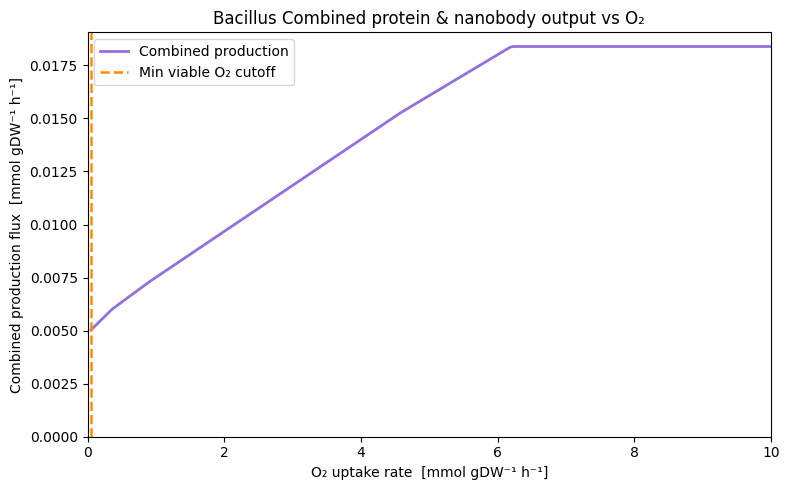

: 

In [ ]:
PROTEIN_RXN_ID  = "GFP_DEMAND"
NANOBODY_RXN_ID = "NB_DEMAND"
o2_rxn_id = "EX_o2_e"

MIN_VIABLE_O2 = 0.0503   # mmol gDW⁻¹ h⁻¹

# ── 1. Calculate max growth for threshold ─────────────
with obj3_aerobic as wt:
    mu_max = wt.optimize().objective_value

viability_threshold = 0.05 * mu_max

def set_production_objective(model):
    model.objective = {
        model.reactions.get_by_id(PROTEIN_RXN_ID) : 0.5,
        model.reactions.get_by_id(NANOBODY_RXN_ID): 0.5,
    }

# ── 2. O₂ scan ────────────────────────────────────────────────────────────────
o2_max_uptake = abs(obj3_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

combined_fluxes = []

with obj3_aerobic as model:
    # Correctly identify biomass reaction inside the context
    biomass_rxn_obj = model.objective.expression.atoms # Get atoms of the linear expression
    # Typically, the first reaction in the objective list is the biomass one
    biomass_rxn = list(model.objective.variables)[0].name.replace('reverse_', '').split('_')[0]
    # Safer way: Use the known biomass ID for yeast-GEM
    model.reactions.bio00006.lower_bound = viability_threshold

    set_production_objective(model)

    for o2 in o2_scan:
        model.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = model.optimize()

        if sol.status == "optimal":
            combined_fluxes.append(sol.fluxes[PROTEIN_RXN_ID] +
                                   sol.fluxes[NANOBODY_RXN_ID])
        else:
            combined_fluxes.append(np.nan)

combined_fluxes = np.array(combined_fluxes)

# ── 3. Production at the minimum viable O₂ cutoff ────────────────────────────
cutoff_idx        = np.argmin(np.abs(o2_scan - MIN_VIABLE_O2))
production_at_min = combined_fluxes[cutoff_idx]

print(f"At minimum viable O₂ ({MIN_VIABLE_O2} mmol gDW⁻¹ h⁻¹):")
print(f"  Combined production flux : {production_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(o2_scan, combined_fluxes, color="mediumpurple", lw=2, label="Combined production")
ax.axvline(MIN_VIABLE_O2, color="darkorange", lw=1.8, ls="--",
           label=f"Min viable O₂ cutoff")

ax.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax.set_ylabel("Combined production flux  [mmol gDW⁻¹ h⁻¹]")
ax.set_xlim(0, o2_max_uptake)
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title("Bacillus Combined protein & nanobody output vs O₂")
plt.tight_layout()
plt.show()